# Neural Network Forecast Review

This notebook evaluates a compact feed-forward neural network for monthly water-demand forecasting. The network uses the shared prepared feature matrix and follows the chronological train, validation, and test protocol.

Input and target scaling are learned from the training window only. The validation period selects the configuration, while the test period remains reserved for final performance assessment.





## Shared forecasting data

The saved feature matrix and chronological split artifacts are loaded directly so this model remains comparable with the seasonal benchmark and Random Forest forecaster.





In [6]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.forecasting_evaluation import (
    evaluate_supervised_model,
    load_phase5_artifacts,
    save_model_run,
)
from src.models.ann import tune_ann

artifacts = load_phase5_artifacts(PROJECT_ROOT)
print('Train rows:', len(artifacts['train_y']))
print('Validation rows:', len(artifacts['validation_y']))
print('Test rows:', len(artifacts['test_y']))
print('Feature count:', artifacts['feature_count'])





Train rows: 108
Validation rows: 24
Test rows: 36
Feature count: 28


## Training-only scaling and validation selection

Several compact network configurations are compared using validation RMSE. Scaling is fitted inside each model using only the training data. Each candidate also monitors the chronological validation window during training and retains its best validation state.





In [7]:
model, tuning_results = tune_ann(
    artifacts['train_X'],
    artifacts['train_y'],
    artifacts['validation_X'],
    artifacts['validation_y'],
)

display(tuning_results.round(3))
print('Selected configuration:', model.parameters)





,configuration_index,hidden_layer_sizes,learning_rate_init,alpha,mae,rmse,mape,smape,r2
0,1,"(64,)",0.001,0.0,227344.522,284796.500,5.921,5.770,0.797
1,2,"(64, 32)",0.000,0.0,281552.317,341585.589,7.244,7.290,0.708
2,0,"(32,)",0.001,0.0,306126.719,381500.096,8.003,7.655,0.636


Selected configuration: {'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001, 'alpha': 0.0001}


In [8]:
evaluation = evaluate_supervised_model(
    model,
    artifacts['train_X'],
    artifacts['train_y'],
    artifacts['validation_X'],
    artifacts['validation_y'],
    artifacts['test_X'],
    artifacts['test_y'],
    fit_model=False,
)

metrics = pd.DataFrame(evaluation['metrics']).T
display(metrics.round(3))





,mae,rmse,mape,smape,r2
validation,227344.522,284796.500,5.921,5.770,0.797
test,375856.590,450990.485,9.510,9.013,0.609


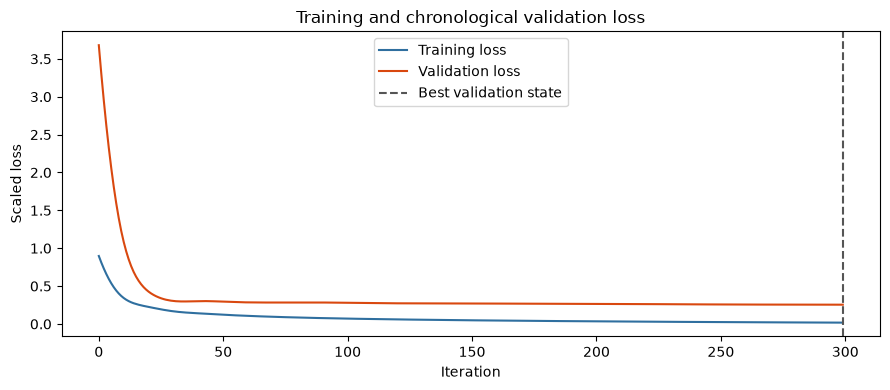

In [9]:
plt.figure(figsize=(9, 4))
plt.plot(model.loss_curve_, label='Training loss', color='#2f6f9f')
plt.plot(model.validation_loss_curve_, label='Validation loss', color='#d9480f')
plt.axvline(model.best_iteration_ - 1, color='#555555', linestyle='--', label='Best validation state')
plt.title('Training and chronological validation loss')
plt.xlabel('Iteration')
plt.ylabel('Scaled loss')
plt.legend()
plt.tight_layout()
plt.show()





{'model': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/models/ann_forecaster.joblib'), 'predictions': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/reports/ann_forecaster_predictions.csv'), 'metrics': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/ann_forecaster_metrics.json'), 'configuration': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/ann_forecaster_configuration.json'), 'residuals': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/reports/ann_forecaster_residuals.csv'), 'residual_diagnostics': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/ann_forecaster_residual_diagnostics.json')}


14907

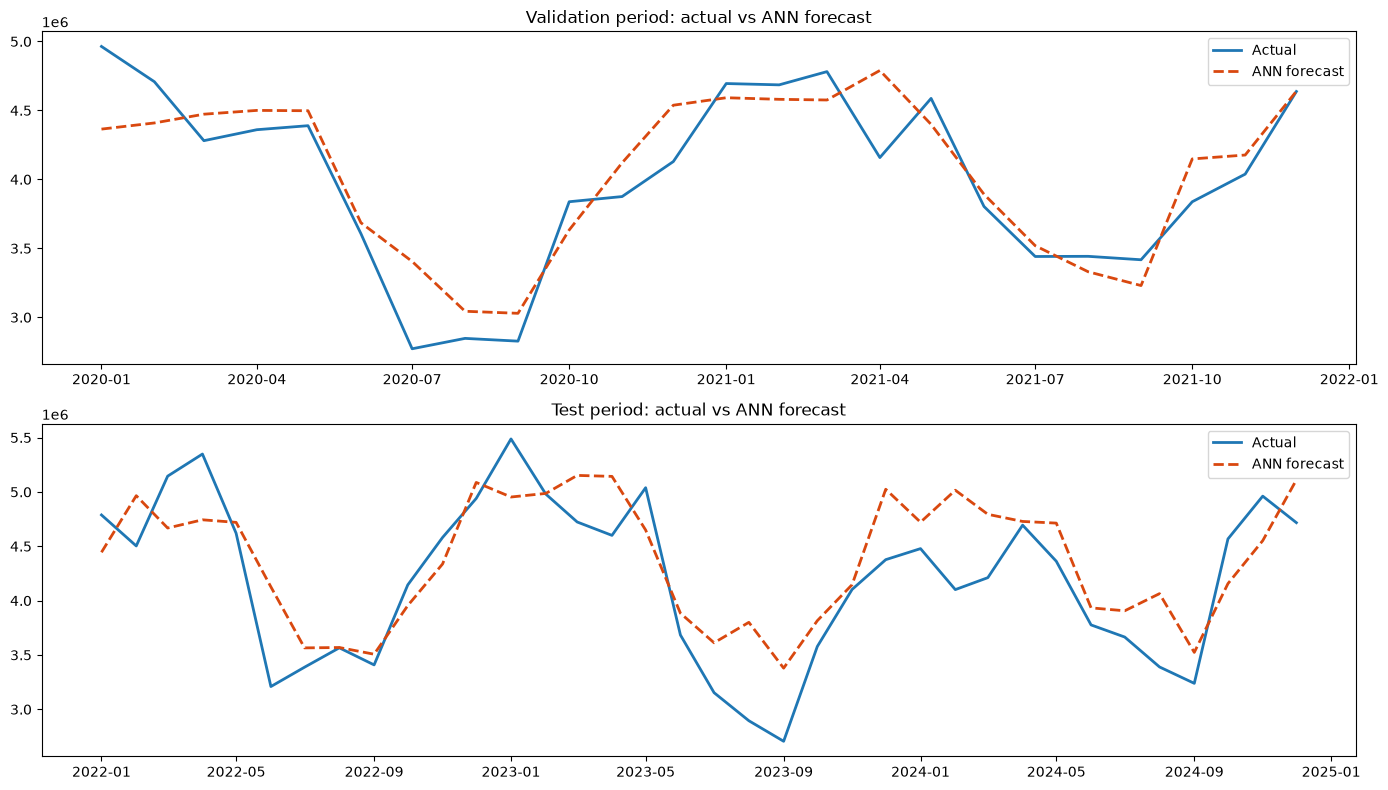

In [10]:
output_dir = PROJECT_ROOT / 'outputs' / 'figures' / 'model_ann'
output_dir.mkdir(parents=True, exist_ok=True)

figure, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for axis, split, actual in zip(axes, ('validation', 'test'), (artifacts['validation_y'], artifacts['test_y'])):
    prediction = evaluation['predictions'][split]
    axis.plot(actual.index, actual.values, label='Actual', color='#1f77b4', linewidth=2)
    axis.plot(prediction.index, prediction.values, label='ANN forecast', color='#d9480f', linewidth=2, linestyle='--')
    axis.set_title(f'{split.title()} period: actual vs ANN forecast')
    axis.legend()
figure.tight_layout()
figure.savefig(output_dir / '01_ann_forecasts.png', dpi=180, bbox_inches='tight')

tuning_results.to_csv(PROJECT_ROOT / 'outputs' / 'metrics' / 'ann_tuning.csv', index=False)
saved_paths = save_model_run(
    'ann_forecaster',
    model,
    evaluation['predictions'],
    evaluation['metrics'],
    {'model': 'MLPRegressor', 'selected_parameters': model.parameters, 'feature_columns': artifacts['feature_columns'], 'scaling': 'training_only', 'validation_monitoring': True, 'best_iteration': model.best_iteration_},
    PROJECT_ROOT,
    targets={'validation': artifacts['validation_y'], 'test': artifacts['test_y']},
)
print(saved_paths)


(PROJECT_ROOT / 'outputs' / 'metrics' / 'ann_validation_loss_curve.json').write_text(json.dumps({
    'training_loss': model.loss_curve_,
    'validation_loss': model.validation_loss_curve_,
    'best_iteration': model.best_iteration_,
}, indent=2))





## Interpretation

The validation period is used to choose a compact architecture and learning rate. Test performance is reported afterward as a held-out comparison. The loss curve helps identify optimization behavior, while the forecast plots show how well the network follows the observed demand trajectory.



